<a href="https://colab.research.google.com/github/Cooljoe67/ML_DSAI/blob/main/07_asymmetric_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Asymmetric Classification
With classification problems, there are different kinds of errors the model can make depending on which classes it confuses for which others. If we imagine a classifier trained to identify plant species, confusing one poisonous plant for another wouldn't be as much of a problem as confusing a poisonous plant with an edible one. These cases, where some kinds of misclassification come with worse consequences than others, are examples of "**Cost Asymmetry**" and are often called "**Asymmetric Classification**" tasks.

With binary classification (where there are only two classes), we denote the two kinds of misclassification "**False Positives**" (where the model predicts positive but the true label is negative) and "**False Negatives**" (where the model predicts negative but the true label is positive). We've seen this distinction before when we looked at confusion matrices which show us the frequencies of the different kinds of misclassification or what we might call "class confusions."

As you read on the LMS, classifiers have a **classification threshold** that we can adjust to trade an increase in one kind of error rate for a decrease in the other. To help us strike the right balance in error rates, **ROC Curves** allow us to visualise all our options for this trade. Each point along the curve shows us a particular pair of error rates that we could select. Once we've chosen one, with a bit of code we can find out what classification threshold corresponds with those scores. Then we can use that threshold when making predictions with the model so that we can strike that desired balance. Let's try it!

---
## 1. Data Loading 🗄️
We'll begin by setting things up with the libraries we need.

In [ ]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split, cross_val_predict, cross_validate, KFold
)
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_curve, auc, confusion_matrix, make_scorer,
    RocCurveDisplay, ConfusionMatrixDisplay
)

For this notebook we'll be looking at a famous dataset used for diagnosing breast cancer. This is a clear case of cost asymmetry where a False Negative, which results in a case going untreated, is far worse that a False Positive, which would come at the cost of some follow-up tests that should reveal the mistake. At a certain point though, the model wouldn't be helpful and could even burden the healthcare system if it was always throwing false alarms. So we must strike some sort of balance while still accounting for the cost asymmetry.

In [ ]:
from sklearn.datasets import load_breast_cancer

# Load the dataset
X, y = load_breast_cancer(return_X_y=True, as_frame=True)

# Perform Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Examine predictor features
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

We can notice some things with this preliminary data exploration:
1. The Dataset is small
    - With only a few hundred samples we'll need to be clever about our cross-validation strategy. It's a good idea to use `KFold` instead of `ShuffleSplit` in this case to make sure all the data is used (with `ShuffleSplit` there can be samples that, by chance, don't end up in any of the splits), and use 10 folds instead of 5 so that the models can be fit to more data each round.
    - A small dataset also means we can afford things like a larger parameter grid because models will be quick to fit to a dataset so small.
    - We'll also most-likely need stronger regularization, because it will be easier to overfit when we have so little data.
2. All the features are numerical
    - This is nice because it means we don't need to worry about having separate numerical and categorical pipelines or spend time trying to optimize the categorical imputation or encoding.
3. There are no missing values
    - We should still always fit an imputer so that the pipeline is capable of making predictions with other data that may be missing values, but it's nice to know that all the training data are real and none of it had to be inferred/imputed.

---
## 2. Baseline Confusion Matrix 🔧
Before we bring in any special techniques, it's good to set up a baseline with a simple classifer out-of-the-box.

Let's see how a Random Forest model performs, visualizing the cross-validation results with a confusion matrix.

CV Accuracy: 0.9582
CV Precision: 0.9588
CV Recall: 0.9755



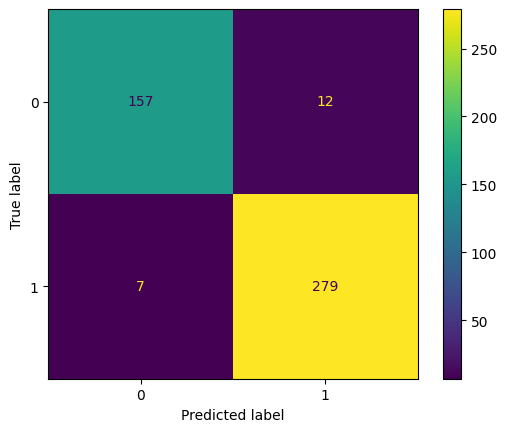

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize model pipeline with imputer, scaler, and classifier
model = make_pipeline(
    SimpleImputer(),
    RandomForestClassifier(random_state=42)
)

# Initialize CV Splitter
splitter = KFold(n_splits=10)
# To measure cross-validation error rates for the confusion matrix, we can use cross_val_predict
cv_preds = cross_val_predict(model, X_train, y_train, cv=splitter)

# Display performance
cv_acc = accuracy_score(y_train, cv_preds)
cv_precision = precision_score(y_train, cv_preds)
cv_recall = recall_score(y_train, cv_preds)

print(
  f'CV Accuracy: {round(cv_acc, 4)}\n'
  f'CV Precision: {round(cv_precision, 4)}\n'
  f'CV Recall: {round(cv_recall, 4)}\n'
)

ConfusionMatrixDisplay.from_predictions(
    y_true=y_train,
    y_pred=cv_preds
);

Remeber how we can interpret these scores:
1. Accuracy: How often was the model correct?
2. Precision: When the model diagnoses "positive" how often is it correct?
3. Recall: Of all the individuals who required treatment, what percentage did the model correctly identify?
4. Confusion Matrix:
    - Top left: number of negative cases (healthy people) correctly classified.
    - Top right: number of False Positives (healthy people incorrectly flagged for treatment).
    - Botton left: number of False Negatives (people in need of treatment that were incorrectly classified as healthy).
    - Bottom right: number of positive cases (people in need of treatment) correctly classified.


These scores seem decent, but we're still seeing 7 False Negatives (2.6% of the people in need of treatment), which come at a high cost. We'd be happy to increase the False Positives a bit if it means we can get those False Negatives closer to zero. The ROC Curve can help us visualise our options for that trade.

---
## 3. Plotting the ROC Curve 📈
Now that we've got a baseline for how our model performs with the default classification threshold, let's see what our options are for different error rates when adjusting this threshold. Maybe we can find a good deal that allows us to get these False Negatives close to 0 without having to admit too many False Positives

In order to plot a ROC Curve, we need the model's probabilistic predictions. We can do that with `model.predict_proba` instead of `model.predict`. Instead of a series of 1s and 0s, this method will return an array with two columns. The first column is the predicted probability that the sample is the negative class, the second is the probablilty that it is positive.

In [ ]:
# Making probabilistic predictions with cross validation
cv_probs = cross_val_predict(model, X_train, y_train, cv=splitter, method='predict_proba')

cv_probs

array([[0.38, 0.62],
       [1.  , 0.  ],
       [0.01, 0.99],
       [0.04, 0.96],
       [0.04, 0.96],
       [1.  , 0.  ],
       [0.28, 0.72],
       [0.  , 1.  ],
       [0.  , 1.  ],
       [1.  , 0.  ],
       [0.01, 0.99],
       [0.99, 0.01],
       [1.  , 0.  ],
       [0.  , 1.  ],
       [0.  , 1.  ],
       [1.  , 0.  ],
       [0.95, 0.05],
       [0.98, 0.02],
       [0.1 , 0.9 ],
       [0.01, 0.99],
       [0.29, 0.71],
       [0.94, 0.06],
       [0.38, 0.62],
       [0.01, 0.99],
       [0.35, 0.65],
       [0.94, 0.06],
       [0.  , 1.  ],
       [1.  , 0.  ],
       [0.  , 1.  ],
       [0.  , 1.  ],
       [0.97, 0.03],
       [0.  , 1.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.64, 0.36],
       [0.  , 1.  ],
       [0.75, 0.25],
       [0.01, 0.99],
       [0.  , 1.  ],
       [0.01, 0.99],
       [0.05, 0.95],
       [1.  , 0.  ],
       [0.99, 0.01],
       [0.01, 0.99],
       [0.07, 0.93],
       [0.  , 1.  ],
       [0.04, 0.96],
       [0.03,

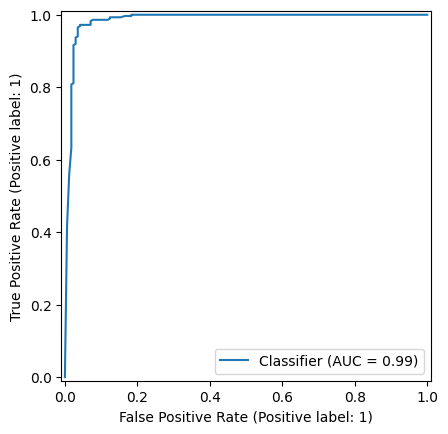

In [ ]:
# The ROC Curve needs just the positive probabilities
cv_pos_probs = cv_probs[:, 1]

# The code for the ROC Curve is very similar to the Confusion Matrix
RocCurveDisplay.from_predictions(
    y_true=y_train,
    y_pred=cv_pos_probs
);

It looks like our model is doing pretty well: the curve hugs the top left corner pretty tightly with a total AUC of 0.99.

If we want to get a sense of the trade we have to make to reduce False Negatives, we can look at this portion of the curve where it is close to or touching the ceiling 1.0 TPR. We can see that, if we want to go all-in reducing False Negatives, there is a threshold at approximately (0.2, 1.0) that allows us to get perfect recall (no False Negatives) as long as we are willing to tolerate a 20% False Positive Rate, which would mean a lot of false alarms, but no one in need of treatment going home misdiagnosed.

(Note: Keep in mind that these scores are from cross-validation, but the scores with the testing data will probably be a little different. Choosing a score with perfect recall in our CV ROC Curve does not guarentee the same performance with testing data or in the real world after we deploy the model).

To get a closer look at the numbers, and to see the thresholds that correspond with them, we can use the `roc_curve` function.

In [ ]:
# Getting all the points on the curve
fpr, tpr, thresholds = roc_curve(y_train, cv_pos_probs)

# Organizing them in a data frame
roc_df = pd.DataFrame({
    'False Positive Rate': fpr,
    'True Positive Rate': tpr,
    'Threshold': thresholds
})

roc_df

,False Positive Rate,True Positive Rate,Threshold
0,0.000000,0.000000,inf
1,0.005917,0.416084,1.00
2,0.011834,0.559441,0.99
3,0.017751,0.632867,0.98
4,0.017751,0.664336,0.97
5,0.017751,0.709790,0.96
6,0.017751,0.723776,0.95
7,0.017751,0.758741,0.93
8,0.017751,0.800699,0.91
9,0.017751,0.807692,0.90


At this point, you can simply scan through this list of options and choose the error balance that looks best for your needs.

---
## 4. Making Predictions with a Custom Threshold ⚡

Once you've chosen an error balance, and found the threshold corresponding with it, we still need to implement that threshold to turn these probabilities into binary predictions.

In [ ]:
# Choose a threshold based on the list above
threshold = 0.18 #perfect recall and some extra wiggle room so its more likely to generalize

# Convert probabilistic predictions into 1s and 0s according to the threshold
cv_thresh_preds = (cv_pos_probs > threshold).astype(int)
cv_thresh_preds

array([1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1,

Let's check the new confusion matrix

CV_thresh Accuracy: 0.9319
CV_thresh Precision: 0.9022
CV_thresh Recall: 1.0



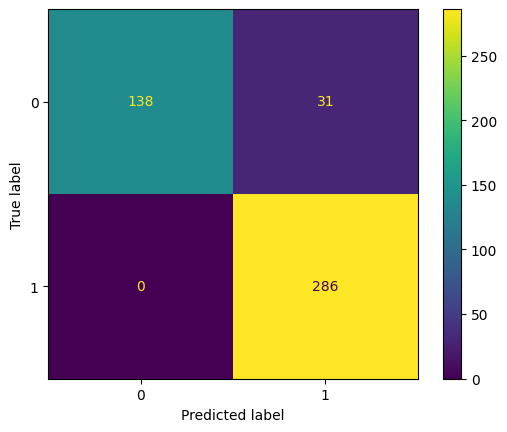

In [ ]:
# Display performance
cv_thresh_acc = accuracy_score(y_train, cv_thresh_preds)
cv_thresh_precision = precision_score(y_train, cv_thresh_preds)
cv_thresh_recall = recall_score(y_train, cv_thresh_preds)

print(
  f'CV_thresh Accuracy: {round(cv_thresh_acc, 4)}\n'
  f'CV_thresh Precision: {round(cv_thresh_precision, 4)}\n'
  f'CV_thresh Recall: {round(cv_thresh_recall, 4)}\n'
)
ConfusionMatrixDisplay.from_predictions(
    y_true=y_train,
    y_pred=cv_thresh_preds
);

This looks great, no more False Negatives!

But we've chosen the threshold specifically to fit this dataset so we were guarenteed that result. The questions is whether this threshold generalizes. Below, as bonus, you can see how to fit the threshold itself using cross-validation. But for now, to keep it simple, we can just check how well it generalizes to the testing data.

CV_thresh Accuracy: 0.9561
CV_thresh Precision: 0.9342
CV_thresh Recall: 1.0



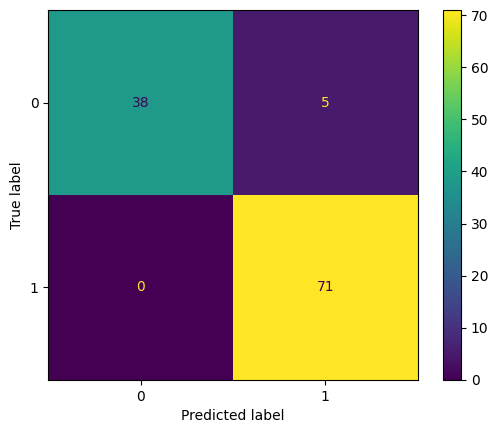

In [ ]:
# Fit the model to the training set
model.fit(X_train, y_train)

# Make predictions on the testing set
probs = model.predict_proba(X_test)[:,1]
preds = (probs > threshold).astype(int)


# Display performance
acc = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds)
recall = recall_score(y_test, preds)

print(
  f'CV_thresh Accuracy: {round(acc, 4)}\n'
  f'CV_thresh Precision: {round(precision, 4)}\n'
  f'CV_thresh Recall: {round(recall, 4)}\n'
)
ConfusionMatrixDisplay.from_predictions(
    y_true=y_test,
    y_pred=preds
);

Looks like the threshold generalizes!

---
## 5. Bonus: Automating Threshold Optimization 🎯

Scanning through the list to decide on a threshold requires manual inspection, and we also risk overfitting the threshold to the training data, even when using cross-validation to make the predictions.

What would be better, is if we could specify some score or balance of scores that we want to maximize, and have the computer automatically search for the best threshold for us. Not only would that save us searching through the list, **we could also nest that optimization process in a cross-validation loop to come up with a threshold that isn't overfit to the training data.**

### 5.1 Setting up a Scorer

In order to automate this process, we'll need to clearly define what we want to optimize. To make this compatible with sklearn's optimization tools, we just have to define a function that, like `accuracy_score`, `recall_score`, etc. takes in the arguments `y_true` and `y_pred` and outputs a score. Then we can use `make_scorer` to make our function compatible with things like `GridSeachCV` and other functions with the `scoring` parameter.

In [ ]:
def cost_balanced_score(y_true, y_pred):

    # Define the costs of the two kinds of error
    fp_cost = 3
    fn_cost = 100

    # Get error frequencies
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Multiply errors by their costs
    total_error = (fp * fp_cost) + (fn * fn_cost)

    # Return negative error (sklearn will try to maximize the score)
    return -total_error

# Turn function into sklearn scorer
cost_balance = make_scorer(cost_balanced_score)

### 5.2 Automatic Threshold Optimization with `TunedThresholdClassifierCV`

Once we have our scorer, sklearn has a helpful class `TunedThresholdClassifierCV` which will do essentially what we did above with `cross_val_predict` and then finding the best threshold. Like we did above, even though the predictions that the ROC Curve is using were made with cross-validation, it is still choosing the threshold based on the full training data. We'll need an extra step to fit the threshold with CV as well.

In [ ]:
from sklearn.model_selection import TunedThresholdClassifierCV

# Setting up the threshold tuner
tuned_thresh_model = TunedThresholdClassifierCV(
    estimator=model,
    scoring=cost_balance,
    cv=splitter
)

tuned_thresh_model.fit(X_train, y_train)
tuned_thresh_model.best_threshold_

np.float64(0.17171717171717174)

Looks like the threshold it came up with is similar to the one we chose manually.

Let's see how it performs!

CV_thresh Accuracy: 0.9561
CV_thresh Precision: 0.9342
CV_thresh Recall: 1.0



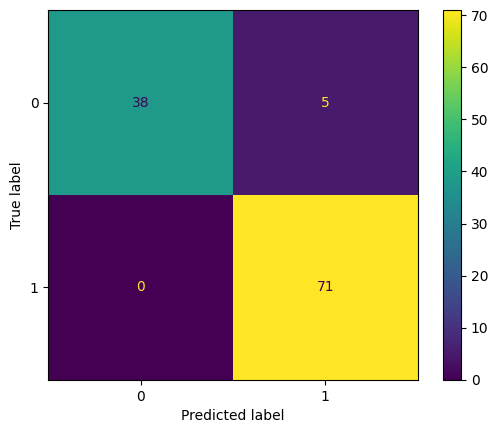

In [ ]:
# The TunedThresholdClassifier automatically uses the threshold when making predictions
preds = tuned_thresh_model.predict(X_test)

# Display performance
acc = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds)
recall = recall_score(y_test, preds)

print(
  f'CV_thresh Accuracy: {round(acc, 4)}\n'
  f'CV_thresh Precision: {round(precision, 4)}\n'
  f'CV_thresh Recall: {round(recall, 4)}\n'
)
ConfusionMatrixDisplay.from_predictions(
    y_true=y_test,
    y_pred=preds
);

Looks like we got the same testing scores, only we didn't need to search though a list of thresholds!

### 5.3 Cross-Validating the Threshold

Right now we are using testing performance, but we really want to hide the testing data until the very end and only use it once. But if we look at our score with the training data it will be misleading, because even though the predictions were made with `cross_val_predict`, we chose the threshold based on the full set of predictions, guarenteeing the error rates that we saw in the ROC Curve. What we really want is for the threshold itself to be based on folds rather than the whole training set.

We can do this by nesting our threshold tuner inside another layer of cross validation and looking at the different thresholds it came up with when fitting to different folds.

In [ ]:
cv_results = cross_validate(
    tuned_thresh_model,
    X_train, y_train,
    cv=splitter, #another layer of 10-Fold CV
    return_estimator=True
)

# Printing the thresholds that the different CV runs came up with
for estimator in cv_results['estimator']:
    print(estimator.best_threshold_)

0.25252525252525254
0.3434343434343435
0.18181818181818182
0.2828282828282829
0.29292929292929293
0.27272727272727276
0.22222222222222224
0.25252525252525254
0.26262626262626265
0.12121212121212122


As we can see from the variation in these best thresholds, it matters which data the `TunedThresholdClassifierCV` was fit to when coming up with the threshold. That's why we shouldn't just trust the one it found with our particular training set like we did originally.

Common practice for finding a more robust threshold is to simply average these different thresholds from the nested CV.

In [ ]:
tuned_threshold = np.mean([estimator.best_threshold_ for estimator in cv_results['estimator']])
tuned_threshold

np.float64(0.24848484848484848)

Let's see how it performs with the testing data

CV_thresh Accuracy: 0.9649
CV_thresh Precision: 0.9467
CV_thresh Recall: 1.0



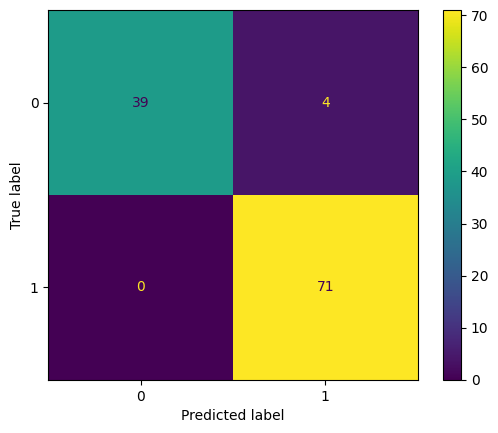

In [ ]:
# Fit the model to the training set
model.fit(X_train, y_train)

# Make predictions on the testing set
probs = model.predict_proba(X_test)[:,1]
preds = (probs > tuned_threshold).astype(int)


# Display performance
acc = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds)
recall = recall_score(y_test, preds)

print(
  f'CV_thresh Accuracy: {round(acc, 4)}\n'
  f'CV_thresh Precision: {round(precision, 4)}\n'
  f'CV_thresh Recall: {round(recall, 4)}\n'
)
ConfusionMatrixDisplay.from_predictions(
    y_true=y_test,
    y_pred=preds
);

Looks like it gave us the best scores we've seen so far!

### 5.4 Other Metrics for Threshold Tuning

As you should have read on the LMS, there are other measures of how optimal a threshold is. **These methods aren't for dealing with the class asymmetry problem** that has been the focus of this notebook because they don't prioritize reducing one kind of error more than another, but they can be helpful for other problems like class imbalance. In general, it can be helpful to optimize the threshold of the model after it has already been fit.

To optimize according to these other metrics, all we have to do is turn them into scorers and then we can run the same code we did before, just optimizing for a different value.

In [ ]:
def youdens_j_score(y_true, y_pred):
    # Get error frequencies
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    # Calculate True Positive Rate and False Positive Rate
    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)
    # Return Youden's J Stat
    return tpr - fpr

def roc_distance_score(y_true, y_pred):
    # Get error frequencies
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    # Calculate True Positive Rate and False Positive Rate
    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)
    # Compute euclidean distance to the ideal (0, 1)
    distance = np.sqrt(fpr**2 + (1 - tpr)**2)
    return distance

youden_scorer = make_scorer(youdens_j_score)
roc_distance_scorer = make_scorer(roc_distance_score)

In [ ]:
# Setting up the threshold tuner
tuned_thresh_model = TunedThresholdClassifierCV(
    estimator=model,
    scoring=youden_scorer, #swap out the scorer
    cv=splitter
)
# Performing nested cross-validation
cv_results = cross_validate(
    tuned_thresh_model,
    X_train, y_train,
    cv=splitter, #another layer of 10-Fold CV
    return_estimator=True
)

youden_tuned_threshold = np.mean([estimator.best_threshold_ for estimator in cv_results['estimator']])
youden_tuned_threshold

np.float64(0.5595959595959596)

Let's see how it performs with the testing data

Youden's J treats both classes equally, so we shouldn't expect as good of a True Positive Rate, and will probably see more balanced errors

CV_thresh Accuracy: 0.9649
CV_thresh Precision: 0.9589
CV_thresh Recall: 0.9859



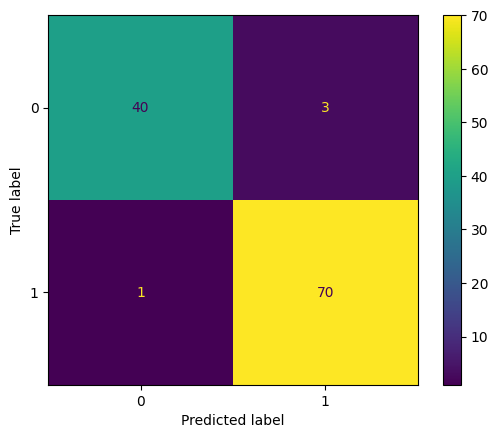

In [ ]:
# Fit the model to the training set
model.fit(X_train, y_train)

# Make predictions on the testing set
probs = model.predict_proba(X_test)[:,1]
preds = (probs > youden_tuned_threshold).astype(int)


# Display performance
acc = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds)
recall = recall_score(y_test, preds)

print(
  f'CV_thresh Accuracy: {round(acc, 4)}\n'
  f'CV_thresh Precision: {round(precision, 4)}\n'
  f'CV_thresh Recall: {round(recall, 4)}\n'
)
ConfusionMatrixDisplay.from_predictions(
    y_true=y_test,
    y_pred=preds
);

---
## 6. Challenge 🍄

Try implementing the same techniques to tune a threshold for this dataset classifying poisonous and edible mushrooms!

How many edible mushrooms can you still eat while being careful not eat any poisonous ones?

In [ ]:
# Import data
url = "https://drive.google.com/file/d/1Op1vQftBKN1lrPVGGLJU-UOlv_dScTup/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
mushroom_data = pd.read_csv(path).set_index('Id')
mushroom_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6499 entries, 6573 to 373
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   cap.shape               6499 non-null   object
 1   cap.color               6499 non-null   object
 2   bruises                 6499 non-null   bool  
 3   stalk.color.above.ring  6499 non-null   object
 4   stalk.color.below.ring  6499 non-null   object
 5   population              6499 non-null   object
 6   poisonous               6499 non-null   int64 
dtypes: bool(1), int64(1), object(5)
memory usage: 361.8+ KB


In contrast to the breast cancer dataset, this one has all categorical features! Once again you don't need a column transformer with separate categorical and numerical pipelines, but you will need an imputer and an encoder to preprocess the data.

In [ ]:
# Your Code Here

### 🏆Competition

Think your model is ready to be put to the test? Now that you've trained and tuned your model it's time to deploy it!

You've foraged some more mushrooms. These ones you don't have the labels for. Ask your model to classify them to sort your harvest into edible and poisonous piles.

Now it's time to eat the edible ones! Upload your model's predictions to the competition app your instructor sent you to see if you ate any poisonous ones! 💀

Who can eat the most 😋 without sending anyone to the hospital? 🤢

In [ ]:
# Loading in unlabeled competition data
url = "https://drive.google.com/file/d/1eWxV9FGj6D-YnMsv4mHMWRcGIKbjrXYL/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
X_foraged = pd.read_csv(path).set_index('Id')

In [ ]:
# Time to put your model to the test!